Mục tiêu: Xây dựng và vẽ biểu đồ so sánh ba mô hình hồi quy (Tuyến tính, Đa thức bậc cao và Ridge Regression) để dự đoán giá bán nhà dựa vào diện tích sống. Mục đích chính là minh họa trực quan sự khác biệt giữa các trạng thái của mô hình học máy: Underfitting (đơn giản hóa quá mức), Overfitting (học thuộc lòng dữ liệu/nhiễu) và sự điều chuẩn bằng Ridge Regression.

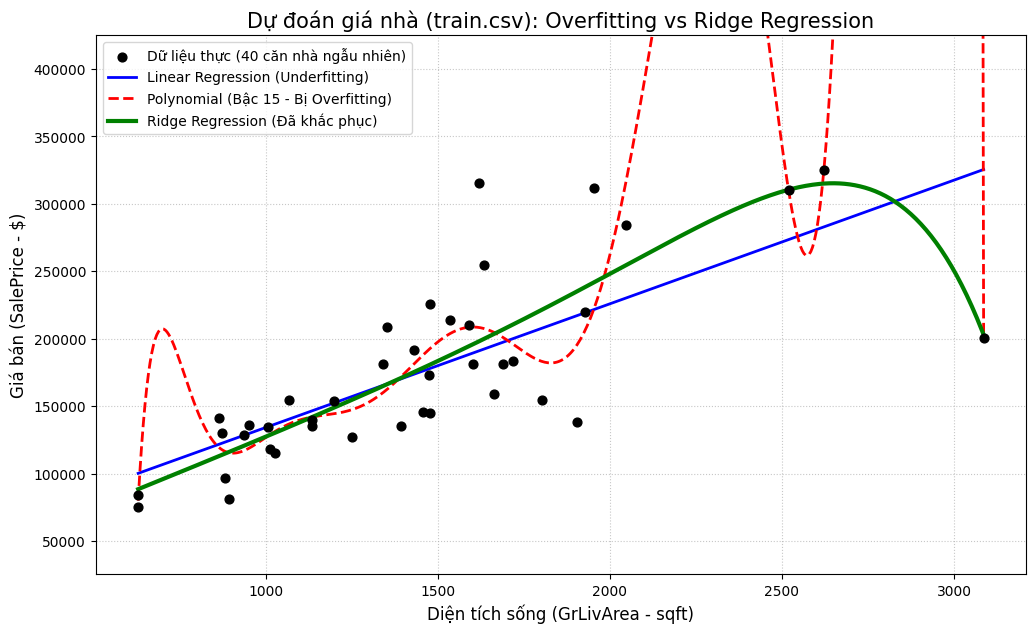

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score

# ==========================================
# 1. ĐỌC VÀ TRÍCH XUẤT DỮ LIỆU TỪ TRAIN.CSV
# ==========================================
# Đọc file dữ liệu Kaggle của bạn
df = pd.read_csv('train.csv')

# Lấy 2 cột cần thiết: Diện tích (GrLivArea) và Giá nhà (SalePrice)
df_subset = df[['GrLivArea', 'SalePrice']]

# Lấy ngẫu nhiên 40 căn nhà để dễ tạo ra Overfitting
df_sample = df_subset.sample(n=40, random_state=42)

# Sắp xếp lại theo diện tích tăng dần để vẽ biểu đồ không bị rối nét


X = df_sample[['GrLivArea']].values
y = df_sample['SalePrice'].values

# Trục X dùng để vẽ đường cong liên tục
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

# ==========================================
# 2. XÂY DỰNG 3 MÔ HÌNH
# ==========================================
# --- Mô hình 1: Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_plot_lin = lin_reg.predict(X_plot)

# --- Mô hình 2: Polynomial Regression (Cố tình Overfit) ---
# Nâng lên đa thức bậc 10 để ép mô hình học thuộc lòng các điểm nhiễu
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X)
X_plot_poly = poly.transform(X_plot)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)
X_plot_poly_scaled = scaler.transform(X_plot_poly)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_scaled, y)
y_plot_poly = poly_reg.predict(X_plot_poly_scaled)

# --- Mô hình 3: Ridge Regression ---
# Phạt mạnh với alpha để duỗi thẳng các đường uốn éo

alpha_to_test = [0.01, 0.1 , 1.0 , 10.0, 50.0 , 100.0, 200.0, 500.0 , 700.0 , 1000.0]
ridge_reg = RidgeCV(alphas = alpha_to_test, cv = 5)
ridge_reg.fit(X_poly_scaled, y)
y_plot_ridge = ridge_reg.predict(X_plot_poly_scaled)

# ==========================================
# 3. VẼ BIỂU ĐỒ
# ==========================================
plt.figure(figsize=(12, 7))

# Điểm dữ liệu thực tế
plt.scatter(X, y, color='black', s=40, zorder=5, label='Dữ liệu thực (40 căn nhà ngẫu nhiên)')

# Các đường dự đoán
plt.plot(X_plot, y_plot_lin, color='blue', linewidth=2, label='Linear Regression (Underfitting)')
plt.plot(X_plot, y_plot_poly, color='red', linestyle='--', linewidth=2, label='Polynomial (Bậc 15 - Bị Overfitting)')
plt.plot(X_plot, y_plot_ridge, color='green', linewidth=3, label='Ridge Regression (Đã khắc phục)')

plt.title('Dự đoán giá nhà (train.csv): Overfitting vs Ridge Regression', fontsize=15)
plt.xlabel('Diện tích sống (GrLivArea - sqft)', fontsize=12)
plt.ylabel('Giá bán (SalePrice - $)', fontsize=12)

# Giới hạn trục Y để đường màu đỏ không làm biến dạng toàn bộ biểu đồ khi nó vọt lên
plt.ylim(y.min() - 50000, y.max() + 100000)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()